In [1]:
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

In [2]:
import numpy as np
import pandas as pd
import matplotlib

In [3]:
df = pd.read_csv("pima-indians-diabetes.data.csv")

In [4]:
df

,6,148,72,35,0,33.6,0.627,50,1
0,1,85,66,29,0,26.6,0.351,31,0
1,8,183,64,0,0,23.3,0.672,32,1
2,1,89,66,23,94,28.1,0.167,21,0
3,0,137,40,35,168,43.1,2.288,33,1
4,5,116,74,0,0,25.6,0.201,30,0
...,...,...,...,...,...,...,...,...,...
762,10,101,76,48,180,32.9,0.171,63,0
763,2,122,70,27,0,36.8,0.340,27,0
764,5,121,72,23,112,26.2,0.245,30,0
765,1,126,60,0,0,30.1,0.349,47,1


In [5]:
df_features = df.iloc[:,0:8]
df_target = df.iloc[:,8]
df_features.head()

,6,148,72,35,0,33.6,0.627,50
0,1,85,66,29,0,26.6,0.351,31
1,8,183,64,0,0,23.3,0.672,32
2,1,89,66,23,94,28.1,0.167,21
3,0,137,40,35,168,43.1,2.288,33
4,5,116,74,0,0,25.6,0.201,30


In [6]:
df_target

0      0
1      1
2      0
3      1
4      0
      ..
762    0
763    0
764    0
765    1
766    0
Name: 1, Length: 767, dtype: int64

In [7]:
X_train, X_test, y_train, y_test = train_test_split(df_features, df_target, test_size=0.20, random_state=0)

In [8]:
model = SVC(kernel="linear", C=1, random_state=0)
model.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=0)

In [9]:
y_pred = model.predict(X_test)

In [10]:
print("Accuracy: ", accuracy_score(y_test, y_pred)*100)

Accuracy:  78.57142857142857


In [11]:
print("confusion_matrix: \n", pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted']))

confusion_matrix: 
 Predicted   0   1
Actual           
0          92   9
1          24  29


In [12]:
print("classification_report: \n", classification_report(y_test, y_pred))

classification_report: 
               precision    recall  f1-score   support

           0       0.79      0.91      0.85       101
           1       0.76      0.55      0.64        53

    accuracy                           0.79       154
   macro avg       0.78      0.73      0.74       154
weighted avg       0.78      0.79      0.78       154



In [13]:
from sklearn.metrics import roc_auc_score, roc_curve,auc

In [14]:
roc_auc_score(y_test, y_pred)

0.7290304502148329

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

C:\Users\bhara\AppData\Local\Temp\ipykernel_10920\1399177361.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

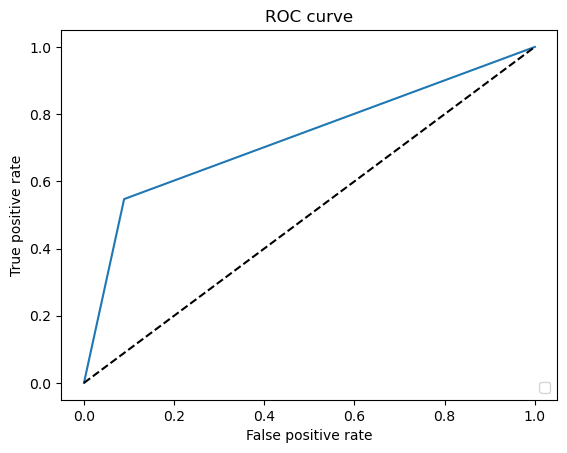

In [15]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.legend(loc="lower right")
plt.title('ROC curve')
plt.show()
